# Bölüm 6: Hugging Face Transformers ile Spam Tespiti (Colab)

Bu notebook, Hugging Face Transformers kütüphanesini kullanarak GPT-2 modelini spam tespiti için fine-tune eder ve Hugging Face'e yükler.

## Kitaptaki Bölüm 6.5 yaklaşımı:
1. GPT-2 ağırlıklarını yükle
2. Tüm parametreleri dondur (freeze)
3. out_head değiştir (768 -> 2)
4. Son transformer bloğunu aç (h[-1])
5. Final LayerNorm aç (ln_f)
6. out_head aç

## 1. Kurulum ve Kütüphaneler

In [1]:
# GPU kontrolü
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan cihaz: {device}")

# Gerekli kütüphaneleri yükle
!pip install transformers pandas numpy torch tqdm matplotlib huggingface_hub datasets -q

Kullanılan cihaz: cuda


## 2. Hugging Face Girişi (Colab Secrets)

In [2]:
from google.colab import userdata
from huggingface_hub import login

# Colab Secrets'tan HF_TOKEN al
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)
print("✅ Hugging Face'e giriş yapıldı!")

✅ Hugging Face'e giriş yapıldı!


## 3. Veri Setini Hugging Face'den Yükle

In [3]:
from datasets import load_dataset

# Hugging Face'den dataset'i yükle
dataset = load_dataset("mustafaege/sms-spam-balanced")

print(dataset)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/77.3k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/14.7k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Label', 'Text'],
        num_rows: 1045
    })
    validation: Dataset({
        features: ['Label', 'Text'],
        num_rows: 149
    })
    test: Dataset({
        features: ['Label', 'Text'],
        num_rows: 300
    })
})


In [4]:
# Pandas DataFrame'e çevir
train_df = dataset['train'].to_pandas()
val_df = dataset['validation'].to_pandas()
test_df = dataset['test'].to_pandas()

print(f"Eğitim: {len(train_df)}, Doğrulama: {len(val_df)}, Test: {len(test_df)}")
print(f"\nEğitim seti örneği:")
print(train_df.head())

Eğitim: 1045, Doğrulama: 149, Test: 300

Eğitim seti örneği:
   Label                                               Text
0      0                Dude how do you like the buff wind.
1      0  Tessy..pls do me a favor. Pls convey my birthd...
2      1  Reminder: You have not downloaded the content ...
3      1  Got what it takes 2 take part in the WRC Rally...
4      1  Shop till u Drop, IS IT YOU, either 10K, 5K, £...


## 4. Dataset Sınıfı

In [5]:
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts = df['Text'].tolist()
        self.labels = df['Label'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

## 5. GPT-2 Yükleme

In [6]:
from transformers import GPT2Model, GPT2Tokenizer
import torch.nn as nn


print("GPT-2 yükleniyor...")
tokenizer = GPT2Tokenizer.from_pretrained("openai-community/gpt2")
tokenizer.pad_token = tokenizer.eos_token

gpt2 = GPT2Model.from_pretrained("openai-community/gpt2")
print(f"Katman: {gpt2.config.n_layer}, Embed: {gpt2.config.n_embd}")

GPT-2 yükleniyor...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Katman: 12, Embed: 768


## 6. Model: Kitaptaki gibi out_head ekleme

In [7]:
# Kitaptaki gibi: out_head ekle (768 -> 2)
gpt2.out_head = nn.Linear(768, 2)
model = gpt2
model.to(device)

print(f"Model hazır!")
print(f"Toplam parametre: {sum(p.numel() for p in model.parameters()):,}")

Model hazır!
Toplam parametre: 124,441,346


## 7. Fine-tuning - Kitaptaki Bölüm 6.5

In [8]:
# Adım 1: Tüm parametreleri dondur
for param in model.parameters():
    param.requires_grad = False

print(f"Donduruldu: {sum(p.numel() for p in model.parameters() if not p.requires_grad):,}")

Donduruldu: 124,441,346


In [9]:
# Adım 2: Belirli katmanları aç (kitaptaki gibi)

# Son transformer bloğunu aç (h[-1])
for param in model.h[-1].parameters():
    param.requires_grad = True

# Final LayerNorm aç (ln_f)
for param in model.ln_f.parameters():
    param.requires_grad = True

# out_head aç
for param in model.out_head.parameters():
    param.requires_grad = True

print(f"Eğitilebilir: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Eğitilebilir: 7,090,946


## 8. DataLoader

In [10]:
from torch.utils.data import DataLoader

train_dataset = SpamDataset(train_df, tokenizer, max_length=128)
val_dataset = SpamDataset(val_df, tokenizer, max_length=128)
test_dataset = SpamDataset(test_df, tokenizer, max_length=128)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print(f"Eğitim batch: {len(train_loader)}")

Eğitim batch: 66


## 9. Eğitim Döngüsü

In [11]:
from torch.optim import AdamW
from tqdm import tqdm

num_epochs = 5
learning_rate = 2e-5

optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

In [12]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(loader, desc="Eğitim"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        # Forward: son token üzerinden
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        last_token = outputs.last_hidden_state[:, -1, :]  # Son token
        logits = model.out_head(last_token)

        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Değerlendirme"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            last_token = outputs.last_hidden_state[:, -1, :]
            logits = model.out_head(last_token)

            loss = criterion(logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

In [13]:
best_val_acc = 0

# Eğitim geçmişini kaydet
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Geçmişe ekle
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Train: {train_loss:.4f} | {train_acc*100:.2f}%")
    print(f"Val: {val_loss:.4f} | {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "spam_classifier.pth")
        print(f"En iyi model kaydedildi!")

print(f"\nEn iyi val acc: {best_val_acc*100:.2f}%")


Epoch 1/5


Değerlendirme: 100%|██████████| 10/10 [00:01<00:00,  9.58it/s]


Train: 2.4583 | 49.00%
Val: 1.2758 | 53.02%
En iyi model kaydedildi!

Epoch 2/5


Değerlendirme: 100%|██████████| 10/10 [00:01<00:00,  9.51it/s]


Train: 0.9285 | 49.09%
Val: 0.5439 | 79.19%
En iyi model kaydedildi!

Epoch 3/5


...

Train: 0.4753 | 77.89%
Val: 0.2486 | 97.32%
En iyi model kaydedildi!

Epoch 4/5


Değerlendirme: 100%|██████████| 10/10 [00:01<00:00,  9.10it/s]


Train: 0.2680 | 89.95%
Val: 0.1067 | 97.32%

Epoch 5/5


Değerlendirme: 100%|██████████| 10/10 [00:01<00:00,  8.84it/s]

Train: 0.1496 | 95.60%
Val: 0.0588 | 97.32%

En iyi val acc: 97.32%


## 10. Loss ve Accuracy Grafikleri

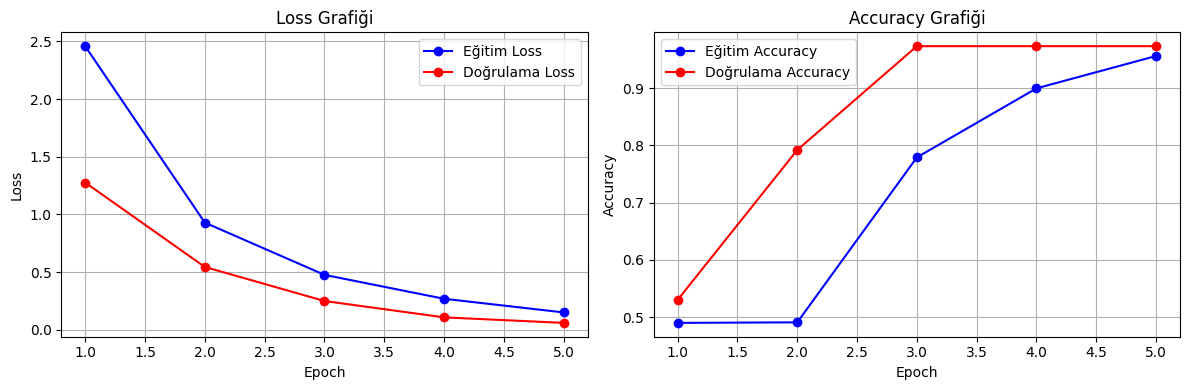

Grafikler kaydedildi: training_plots.png


In [14]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

# Loss grafiği
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], 'b-o', label='Eğitim Loss')
plt.plot(epochs, history['val_loss'], 'r-o', label='Doğrulama Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Grafiği')
plt.legend()
plt.grid(True)

# Accuracy grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], 'b-o', label='Eğitim Accuracy')
plt.plot(epochs, history['val_acc'], 'r-o', label='Doğrulama Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Grafiği')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafikler kaydedildi: training_plots.png")

## 11. Test Değerlendirmesi

In [15]:
model.load_state_dict(torch.load("spam_classifier.pth"))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test: {test_acc*100:.2f}%")

Değerlendirme: 100%|██████████| 19/19 [00:02<00:00,  8.41it/s]

Test: 94.00%


## 12. Hugging Face'e Yükleme

In [16]:
import os

# HF formatında kaydet
output_dir = "./hf_spam_model"
os.makedirs(output_dir, exist_ok=True)

# Model ve tokenizer kaydet
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Model {output_dir} klasörüne kaydedildi!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model ./hf_spam_model klasörüne kaydedildi!


In [17]:
from huggingface_hub import HfApi, create_repo, upload_folder

# Repository ID
repo_id = "mustafaege/spam-detector-gpt2-hf"

# Repository oluştur (varsa hata verme)
create_repo(repo_id, exist_ok=True)
print(f"Repository: https://huggingface.co/{repo_id}")

Repository: https://huggingface.co/mustafaege/spam-detector-gpt2-hf


In [18]:
# Model dosyalarını yükle
api = HfApi()

api.upload_folder(
    folder_path=output_dir,
    repo_id=repo_id,
    repo_type="model",
    commit_message="Upload fine-tuned GPT-2 spam detector model"
)

print(f"\n✅ Model başarıyla yüklendi!")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...m_model/model.safetensors:   9%|9         | 45.1MB /  498MB            


✅ Model başarıyla yüklendi!


In [19]:
# Eğitim grafiklerini de yükle
api.upload_file(
    path_or_fileobj="training_plots.png",
    path_in_repo="training_plots.png",
    repo_id=repo_id,
    repo_type="model",
    commit_message="Upload training plots"
)
print("✅ Eğitim grafikleri yüklendi!")

✅ Eğitim grafikleri yüklendi!


## 13. Modeli Test Et (HF Pipeline)

In [20]:
from transformers import pipeline

# Modeli pipeline ile test et
classifier = pipeline("text-classification", model=repo_id)

# Spam test
result = classifier("Congratulations! You've won a free prize! Click here now!")
print(f"Spam test: {result}")

# Normal mesaj test
result = classifier("Hey, are we still meeting tomorrow?")
print(f"Normal test: {result}")

config.json:   0%|          | 0.00/954 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: mustafaege/spam-detector-gpt2-hf
Key             | Status     | 
----------------+------------+-
out_head.weight | UNEXPECTED | 
out_head.bias   | UNEXPECTED | 
score.weight    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Spam test: [{'label': 'LABEL_0', 'score': 0.9400593042373657}]
Normal test: [{'label': 'LABEL_0', 'score': 0.9814749956130981}]


## Özet

Kitaptaki Bölüm 6.5 ile aynı:
- out_head değiştirildi (768 -> 2)
- h[-1] açıldı
- ln_f açıldı
- out_head açıldı
- Son token üzerinden sınıflandırma

Dataset: mustafaege/sms-spam-balanced
Model URL: https://huggingface.co/mustafaege/spam-detector-gpt2-hf